In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [3]:
df = pd.read_csv('./data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

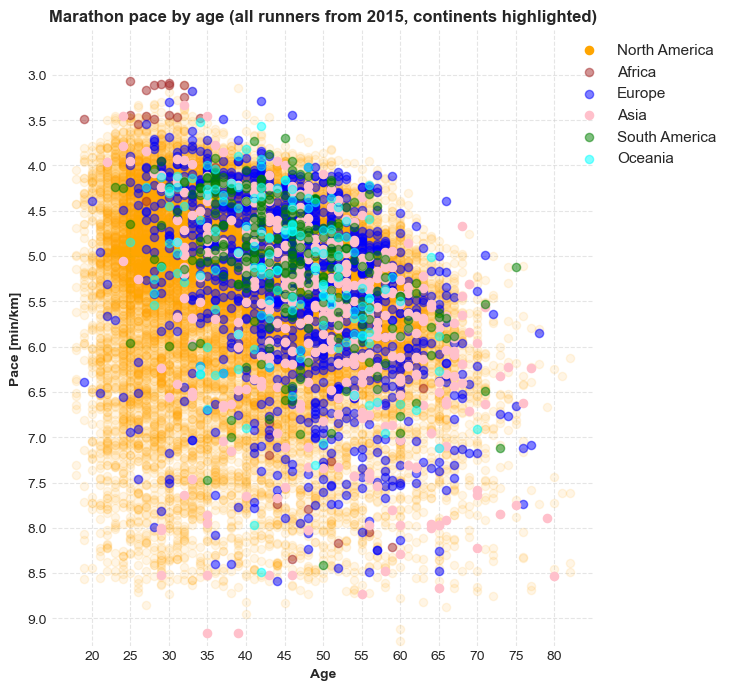

In [5]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
# ax.scatter(x, y, color='orange', s=100, alpha=0.1)
ax.scatter([],[], s=35, color=continent_colors['North America'], label='North America')
# highlight
subset_na = subset15[subset15['Continent'] == 'North America']
x = subset_na['Age']
y = subset_na['Pace']
ax.scatter(x, y, color=continent_colors['North America'], s=35, alpha=0.1)

for continent, color in continent_colors.items():
    a = 0.5
    if continent == 'North America':
        continue
    elif continent == 'Asia':
        a = 1
    subset_tmp = subset15[subset15['Continent'] == continent]
    x = subset_tmp['Age']
    y = subset_tmp['Pace']
    ax.scatter(x, y, color=color, s=35, alpha=a, label=continent)

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, continents highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.25,1))

plt.savefig('charts/scatter_age-pace_continents_2015.png', dpi=300, bbox_inches='tight')
plt.show()

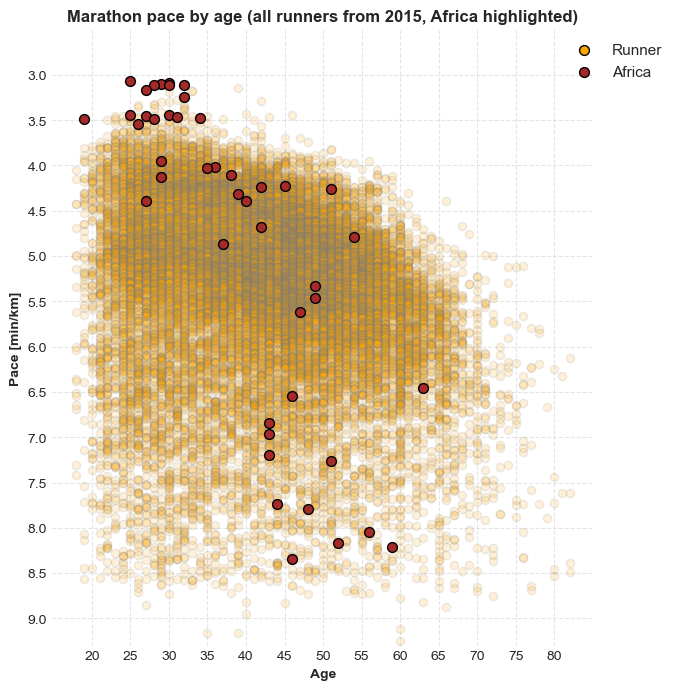

In [6]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
ax.scatter(x, y, color='orange', s=35, alpha=0.15, edgecolor='gray')
ax.scatter([],[], s=50, color='orange', label='Runner', edgecolor='black')
# highlight

continent = 'Africa'
subset_tmp = subset15[subset15['Continent'] == continent]
x = subset_tmp['Age']
y = subset_tmp['Pace']
ax.scatter(x, y, color=continent_colors[continent], s=50, alpha=1, label=continent, edgecolor='black')

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, Africa highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.15,1))

plt.savefig('charts/scatter_age-pace_africa_2015.png', dpi=300, bbox_inches='tight')
plt.show()

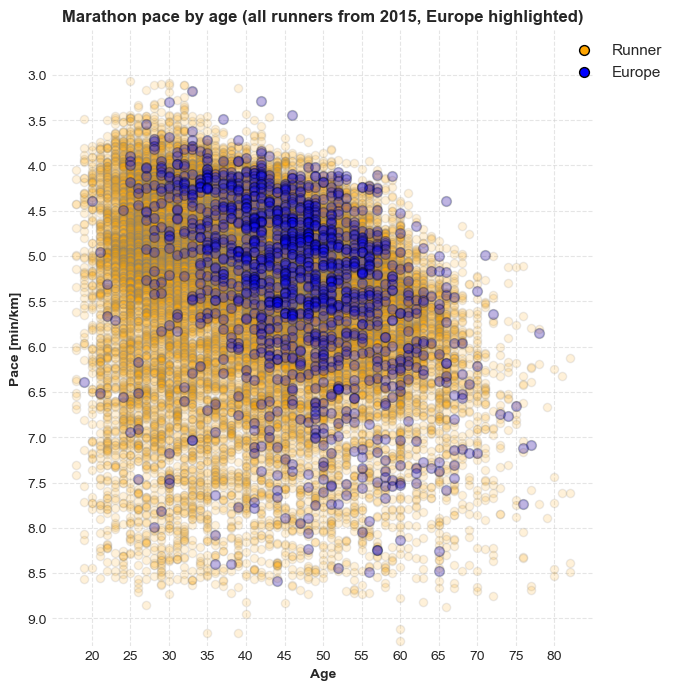

In [7]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
ax.scatter(x, y, color='orange', s=35, alpha=0.15, edgecolor='gray')
ax.scatter([],[], s=50, color='orange', label='Runner', edgecolor='black')
# highlight

continent = 'Europe'
subset_tmp = subset15[subset15['Continent'] == continent]
x = subset_tmp['Age']
y = subset_tmp['Pace']
ax.scatter(x, y, color=continent_colors[continent], s=50, alpha=0.25, edgecolor='black')
ax.scatter([],[], s=50, color=continent_colors[continent], label=continent, edgecolor='blacK')

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, Europe highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.15,1))

plt.savefig('charts/scatter_age-pace_europe_2015.png', dpi=300, bbox_inches='tight')
plt.show()

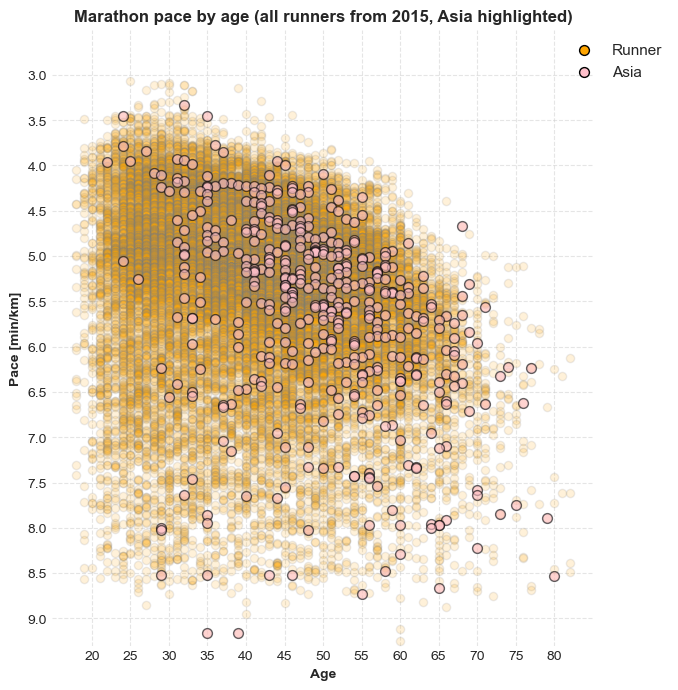

In [8]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
ax.scatter(x, y, color='orange', s=35, alpha=0.15, edgecolor='gray')
ax.scatter([],[], s=50, color='orange', label='Runner', edgecolor='black')
# highlight

continent = 'Asia'
subset_tmp = subset15[subset15['Continent'] == continent]
x = subset_tmp['Age']
y = subset_tmp['Pace']
ax.scatter(x, y, color=continent_colors[continent], s=50, alpha=0.6, edgecolor='black')
ax.scatter([],[], s=50, color=continent_colors[continent], label=continent, edgecolor='blacK')

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, Asia highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.15,1))

plt.savefig('charts/scatter_age-pace_asia_2015.png', dpi=300, bbox_inches='tight')
plt.show()

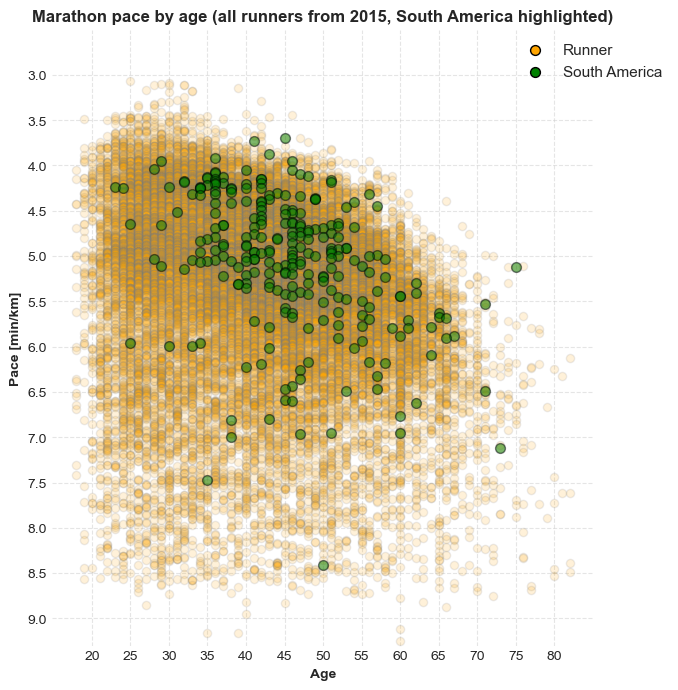

In [9]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
ax.scatter(x, y, color='orange', s=35, alpha=0.15, edgecolor='gray')
ax.scatter([],[], s=50, color='orange', label='Runner', edgecolor='black')
# highlight

continent = 'South America'
subset_tmp = subset15[subset15['Continent'] == continent]
x = subset_tmp['Age']
y = subset_tmp['Pace']
ax.scatter(x, y, color=continent_colors[continent], s=50, alpha=0.5, edgecolor='black')
ax.scatter([],[], s=50, color=continent_colors[continent], label=continent, edgecolor='blacK')

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, South America highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.15,1))

plt.savefig('charts/scatter_age-pace_southamerica_2015.png', dpi=300, bbox_inches='tight')
plt.show()

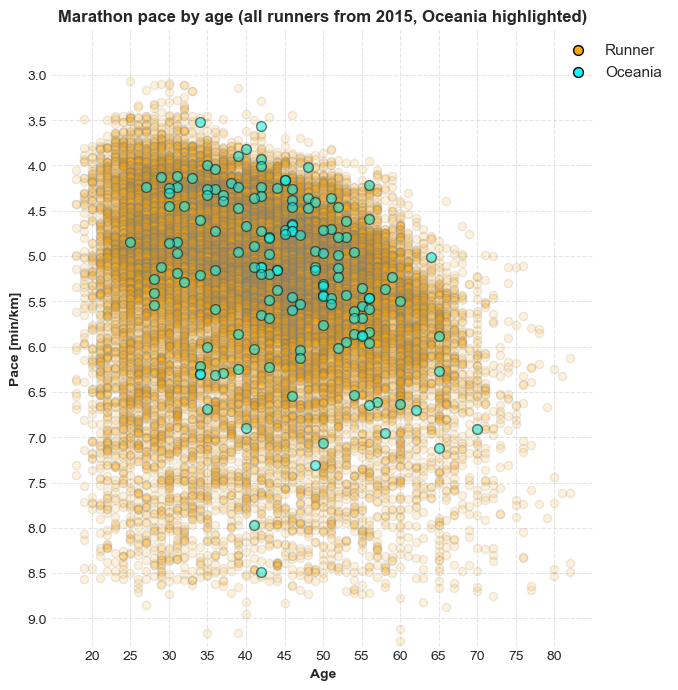

In [10]:
fig, ax = plt.subplots(figsize=(7,8))

# data
subset15 = df[df['Year'] == 2015]
x = subset15['Age']
y = subset15['Pace']
## create
# main
ax.scatter(x, y, color='orange', s=35, alpha=0.15, edgecolor='gray')
ax.scatter([],[], s=50, color='orange', label='Runner', edgecolor='black')
# highlight

continent = 'Oceania'
subset_tmp = subset15[subset15['Continent'] == continent]
x = subset_tmp['Age']
y = subset_tmp['Pace']
ax.scatter(x, y, color=continent_colors[continent], s=50, alpha=0.5, edgecolor='black')
ax.scatter([],[], s=50, color=continent_colors[continent], label=continent, edgecolor='blacK')

## ax settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(20,81,5))
# y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_ylim(2.5,9.3)
ax.set_yticks(np.arange(3,9.1,0.5))
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon pace by age (all runners from 2015, Oceania highlighted)', weight='bold')
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)
# legend
ax.legend(fontsize=11, bbox_to_anchor=(1.15,1))

plt.savefig('charts/scatter_age-pace_oceania_2015.png', dpi=300, bbox_inches='tight')
plt.show()